# Module 04 Lab: Simulating Spiking Neurons
**ITAI 4374: Neuroscience as a Model for AI** | Houston City College | Spring 2026

---

In this lab, you will build a spiking neuron simulation from scratch. You will implement a Leaky Integrate-and-Fire (LIF) neuron, encode data as spikes, connect a small network, and run experiments.

**How to use this notebook:**
- Read each markdown cell for context and instructions
- Complete the code cells where you see `# YOUR CODE HERE`
- Answer all **Knowledge Check** and **Reflection** questions in the markdown cells provided
- Run cells in order with `Shift+Enter`

> **File naming:** Before you start, rename this notebook:  
> `L04_FirstName_LastName_ITAI4374.ipynb`  
> File → Rename (in Colab)

---
## Part A: Setup and Your First LIF Neuron

### Step 1: Import Libraries
Run this cell to set up your environment. If you see "Setup complete!" you're good to go.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

print('Setup complete!')

Setup complete!


### Step 2: The LIF Equation

The Leaky Integrate-and-Fire neuron is the simplest model that captures spiking behavior. Here's the equation in discrete time:

$$V[t+1] = V[t] + dt \cdot \left( \frac{-(V[t] - V_{rest})}{\tau} + \frac{I[t]}{C} \right)$$

Where:
- **V** = membrane potential (the neuron's "voltage")
- **V_rest** = resting potential (what V returns to with no input)
- **τ (tau)** = membrane time constant (how fast voltage leaks away)
- **I** = input current
- **C** = membrane capacitance
- **dt** = time step

Think of it like a **leaky bucket**: current pours in (I), but voltage constantly leaks back toward rest. If enough current accumulates to push V above a **threshold**, the neuron fires a spike and resets.

### Step 3: Define Parameters
Run this cell to set up your neuron's parameters.

In [2]:
# ============ Simulation Parameters ============
dt = 0.001          # Time step (1 ms)
T  = 1.0            # Total simulation time (1 second)
time = np.arange(0, T, dt)  # Time array

# ============ Neuron Parameters ============
V_rest    = -70.0    # Resting potential (mV)
V_thresh  = -55.0    # Spike threshold (mV)
V_reset   = -75.0    # Reset potential after spike (mV)
tau       = 0.020    # Membrane time constant (20 ms)
C         = 1.0      # Membrane capacitance (normalized)

print(f'Simulation: {T}s with {len(time)} time steps')
print(f'Threshold: {V_thresh} mV, Rest: {V_rest} mV')

Simulation: 1.0s with 1000 time steps
Threshold: -55.0 mV, Rest: -70.0 mV


### ✅ Knowledge Check 1
Answer in the cell below:
1. Why is `V_reset` (-75 mV) set *lower* than `V_rest` (-70 mV)? What biological phenomenon does this represent?
2. The time constant `tau` is 20 ms. In plain English, what does this control?

*Your answers here:*

1. V_reset is lower than V_rest because after a neuron fires, it briefly becomes more negative than normal. This represents hyperpolarization and helps prevent the neuron from firing again immediately (refractory period).

2. The time constant τ controls how quickly the neuron’s voltage changes. A larger τ means it changes more slowly, and a smaller τ means it responds faster.

### Step 4: Build the LIF Simulation

Now implement the core simulation loop. You need to:
1. Compute the voltage change (dV) using the LIF equation
2. Update the membrane potential
3. Check if voltage crossed the threshold → if yes, record the spike and reset

**Read the comments carefully — they tell you exactly what to do.**

In [3]:
# ============ Input Current ============
# Constant current injection: 15 nA from t=200ms to t=800ms
I_input = np.zeros(len(time))
I_input[200:800] = 15.0

# ============ Storage Arrays ============
V = np.zeros(len(time))   # Membrane potential over time
V[0] = V_rest             # Start at resting potential
spikes = []               # Store spike times

# ============ Simulation Loop ============
for t in range(len(time) - 1):

    # TODO 1: Compute voltage change using the LIF equation
    # dV = dt * ( -(V[t] - V_rest) / tau + I_input[t] / C )
    dV = dt * (-(V[t] - V_rest) / tau + I_input[t] / C)

    # TODO 2: Update the membrane potential
    # V at next time step = V at current step + dV
    V[t+1] = V[t] + dV

    # TODO 3: Check if voltage crossed the threshold
    # If V[t+1] >= V_thresh:
    #   - Append time[t+1] to the spikes list
    #   - Reset V[t+1] to V_reset
    # YOUR CODE HERE

print(f'Neuron fired {len(spikes)} spikes')

Neuron fired 0 spikes


> **💡 Tip:** If your neuron fires 0 spikes, double-check your dV equation — make sure the signs are right. If it fires thousands, make sure you reset V to `V_reset` (not `V_rest`) after each spike.
>
> **✅ Checkpoint:** Your neuron should fire roughly 10–25 spikes with these parameters.

### Step 5: Visualize the Membrane Potential

Create a plot with two subplots:
- **Top:** Membrane potential over time (with a dashed line at the threshold)
- **Bottom:** Input current over time

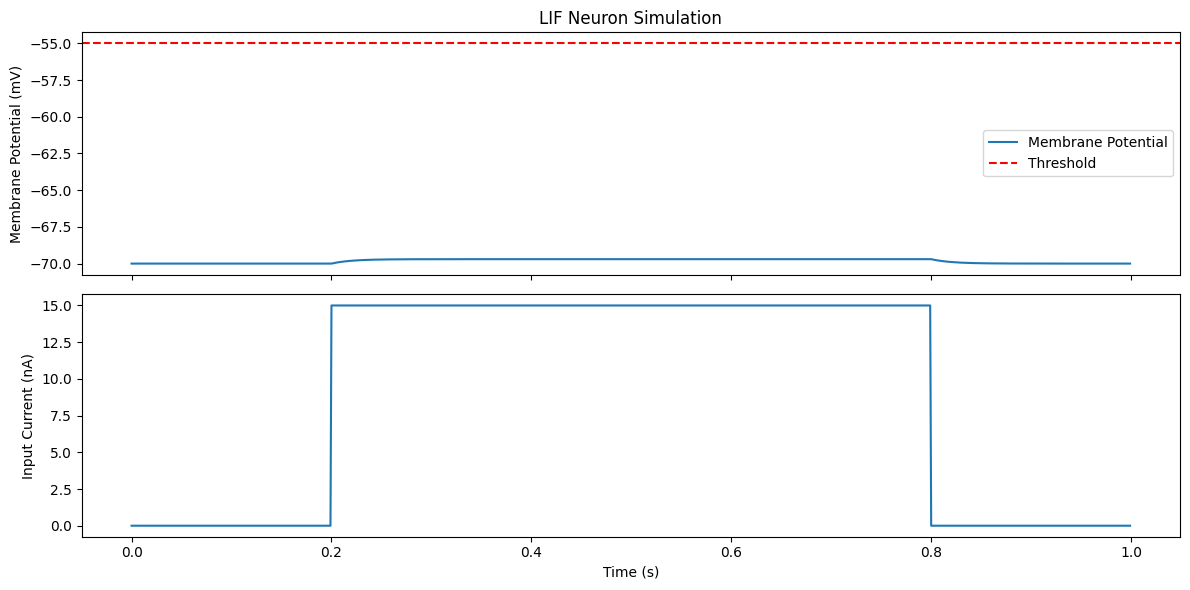

In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# TODO 4: Plot membrane potential on ax1
# - Plot V over time
# - Add a horizontal dashed line at V_thresh
#   Hint: ax1.axhline(y=V_thresh, color='r', linestyle='--', label='Threshold')
ax1.plot(time, V, label='Membrane Potential')
ax1.axhline(y=V_thresh, color='r', linestyle='--', label='Threshold')

ax1.set_ylabel('Membrane Potential (mV)')
ax1.set_title('LIF Neuron Simulation')
ax1.legend()

# TODO 5: Plot the input current on ax2
ax2.plot(time, I_input, label='Input Current')

ax2.set_ylabel('Input Current (nA)')
ax2.set_xlabel('Time (s)')

plt.tight_layout()
plt.show()

### ✅ Knowledge Check 2
Look at your plot and answer:
1. What happens to V *between* spikes — does it go straight up, or does it curve? Why?
2. What happens to V *after* the current turns off (t > 0.8s)? Explain why.

*Your answers here:*

1. Between spikes, the voltage curves upward instead of rising straight. This happens because of the leak term, which slows the increase as the voltage gets farther from resting potential.

2. After the current turns off, the voltage gradually returns to the resting potential. Without input, the leak causes it to decay back down smoothly.

### 💭 Reflection 1
Look at your membrane potential trace. In the booklet, you learned that biological neurons show similar integrate-and-fire behavior. What aspects of your plot look "realistic" compared to real neurons? What looks overly simplified?

*Your reflection here:*
The gradual build-up and reset after threshold look realistic compared to real neurons. However, the model is simplified because it doesn’t show the full spike shape and instantly resets the voltage instead of modeling detailed ion channel behavior.



---
## Part B: Encoding Data as Spikes

Real brains don't receive numbers or pixel values — they receive spikes. To feed data into a spiking neural network, we need to convert regular numbers into spike trains.

The two main strategies are:
- **Rate coding:** Higher values → more spikes per second
- **Temporal coding:** Higher values → earlier spike time

### Step 6: Rate Coding

In rate coding, at each time step we generate a random number between 0 and 1. If the random number is less than the pixel intensity, we emit a spike.

Think of it this way: a value of 0.9 has a 90% chance of spiking at each time step (lots of spikes). A value of 0.1 has only a 10% chance (few spikes).

**Complete the function below:**

In [7]:
def rate_encode(values, num_steps=100):
    """
    Convert an array of values (0 to 1) into spike trains using rate coding.

    Args:
        values: 1D numpy array with values between 0 and 1
        num_steps: number of time steps to simulate
    Returns:
        spikes: 2D array (num_steps, len(values)) where 1=spike, 0=no spike
    """
    num_neurons = len(values)
    spikes = np.zeros((num_steps, num_neurons))

    for t in range(num_steps):
        # TODO 6: Generate random numbers and compare to values
        # If random < value → spike (1), otherwise no spike (0)
        # Hint: np.random.rand(num_neurons) gives an array of random numbers
        # Hint: (random_array < values) gives True/False, use .astype(float)
      spikes[t] = (np.random.rand(num_neurons) < values).astype(float)

    return spikes

**Test your function:**

In [8]:
# Test with 5 values of increasing intensity
test_values = np.array([0.1, 0.3, 0.5, 0.7, 0.9])
test_spikes = rate_encode(test_values, num_steps=200)

# Count spikes per neuron — higher values should produce more spikes
for i, v in enumerate(test_values):
    count = test_spikes[:, i].sum()
    print(f'Value {v:.1f} -> {count:.0f} spikes in 200 steps')

Value 0.1 -> 21 spikes in 200 steps
Value 0.3 -> 60 spikes in 200 steps
Value 0.5 -> 93 spikes in 200 steps
Value 0.7 -> 134 spikes in 200 steps
Value 0.9 -> 178 spikes in 200 steps


> **✅ Checkpoint:** Value 0.9 should have roughly ~180 spikes, value 0.1 roughly ~20. Exact numbers vary (it's random), but the trend should be clear: higher values → more spikes.

### Step 7: Temporal Coding

In temporal coding, information is in **when** a spike happens, not how many. Higher values spike earlier, lower values spike later (or not at all). Think of it as urgency: important signals arrive first.

**Complete the function below:**

In [9]:
def temporal_encode(values, num_steps=100, threshold=0.05):
    """
    Convert values (0 to 1) into spike trains using time-to-first-spike.
    Higher values spike earlier.

    Args:
        values: 1D numpy array with values between 0 and 1
        num_steps: number of time steps
        threshold: minimum value to produce a spike
    Returns:
        spikes: 2D array (num_steps, len(values))
    """
    num_neurons = len(values)
    spikes = np.zeros((num_steps, num_neurons))

    for i in range(num_neurons):
        if values[i] > threshold:
            # TODO 7: Calculate spike time
            # Higher values should spike at EARLIER time steps
            # spike_time = int((1 - values[i]) * (num_steps - 1))
            # This maps value=1.0 → time=0 and value≈0 → time≈num_steps
            spike_time = int((1 - values[i]) * (num_steps - 1))
            spikes[spike_time, i] = 1

    return spikes

### Step 8: Visualize and Compare Both Encodings

Apply both encoding methods to the same data and create **raster plots** — scatter plots where each dot represents a spike.

For a raster plot you need:
```python
times, neurons = np.where(spike_array == 1)
ax.scatter(times, neurons, s=1, color='black')
```

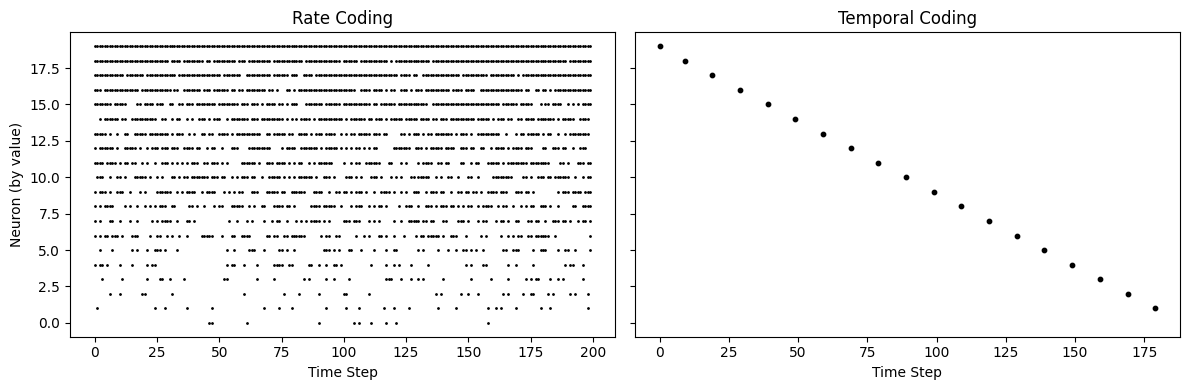

In [10]:
# Create a test signal: 20 values from 0.05 to 1.0
signal = np.linspace(0.05, 1.0, 20)

# Encode with both methods
rate_spks = rate_encode(signal, num_steps=200)
temp_spks = temporal_encode(signal, num_steps=200)

# TODO 8: Create a figure with 2 subplots side by side
# Left subplot: raster plot for rate coding
# Right subplot: raster plot for temporal coding
# Label axes: x = 'Time Step', y = 'Neuron (by value)'
# Title each subplot: 'Rate Coding' and 'Temporal Coding'
#
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# --- Rate coding raster ---
times, neurons = np.where(rate_spks == 1)
ax1.scatter(times, neurons, s=1, color='black')
ax1.set_title('Rate Coding')
ax1.set_xlabel('Time Step')
ax1.set_ylabel('Neuron (by value)')

# --- Temporal coding raster ---
times, neurons = np.where(temp_spks == 1)
ax2.scatter(times, neurons, s=10, color='black')  # s can be a little bigger since it's one spike each
ax2.set_title('Temporal Coding')
ax2.set_xlabel('Time Step')

plt.tight_layout()
plt.show()


> **✅ Checkpoint:** Rate coding raster: scattered dots, denser at top (high-value neurons). Temporal coding raster: a diagonal line — high-value neurons spike on the left, low-value on the right.

### ✅ Knowledge Check 3
1. In rate coding, what information is lost about the original signal? What is preserved?
2. In temporal coding, why might it be *faster* for a downstream neuron to make a decision compared to rate coding?
3. Can you think of a real-world example where timing matters more than frequency? (Hint: sound localization)

*Your answers here:*

1. In rate coding, the exact timing of spikes is lost, but the overall intensity of the signal is preserved through spike frequency.

2. Temporal coding can be faster because a neuron only needs one early spike to make a decision, instead of waiting to count many spikes over time.

3. A real-world example is sound localization. The brain compares tiny timing differences between ears to figure out where a sound is coming from, so timing matters more than frequency.

### 💭 Reflection 2
Compare your two raster plots. Which encoding would be better for a system that needs to react quickly? Which for precise measurements? The brain uses both strategies in different circuits — why do you think that is?

*Your reflection here:*
Temporal coding would be better for systems that need to react quickly because information is available from the first spike. Rate coding is better for precise measurements since averaging many spikes reduces noise. The brain likely uses both because some tasks require speed, while others require accuracy.


---
## Part C: Connect a Mini Spiking Network

A single neuron is interesting, but brains are **networks**. Now you will connect multiple LIF neurons with synaptic weights.

The idea: when neuron A fires a spike, it sends current to neuron B. The amount depends on the **synaptic weight** between them.
- **Positive weight** = excitatory (helps B fire)
- **Negative weight** = inhibitory (prevents B from firing)

### Network Architecture
We'll build a 5-neuron network:
- Neurons 0, 1: **Input** (receive external current)
- Neurons 2, 3: **Hidden** (receive input from 0 and 1)
- Neuron 4: **Output** (receives input from 2 and 3)

In [17]:
# Network parameters
N = 5  # Number of neurons
T_net = 0.5
time_net = np.arange(0, T_net, dt)
steps = len(time_net)

# Weight matrix: weights[i, j] = connection from neuron i to neuron j
weights = np.zeros((N, N))
weights[0, 2] = 2000.0   # Neuron 0 → 2 (excitatory) - Increased further for firing
weights[1, 3] = 2000.0   # Neuron 1 → 3 (excitatory) - Increased further for firing
weights[2, 4] = 2000.0   # Neuron 2 → 4 (excitatory) - Increased further for firing
weights[3, 4] = 2000.0   # Neuron 3 → 4 (excitatory) - Increased further for firing

# External input: only to neurons 0 and 1
I_ext = np.zeros((steps, N))
I_ext[100:400, 0] = 1500.0   # Neuron 0 gets current - Increased further
I_ext[150:350, 1] = 1500.0   # Neuron 1 gets current (slightly offset) - Increased further

# Storage
V_net = np.full((steps, N), V_rest)
spike_log = [[] for _ in range(N)]  # Spike times per neuron
just_spiked = np.zeros(N, dtype=bool)  # Track spikes at current step

# ============ Simulation Loop ============
for t in range(steps - 1):
    just_spiked[:] = False

    # Calculate synaptic input from previous spikes
    synaptic_input = np.zeros(N)
    if t > 0: # Check for spikes from the *previous* time step
        for n_prev_step in range(N):
            # A neuron's voltage is set to V_reset for the *next* time step
            # So, if V_net[t, n_prev_step] == V_reset, it means it spiked at t-1
            if V_net[t, n_prev_step] == V_reset:
                synaptic_input += weights[n_prev_step, :]

    for n in range(N):
        # TODO 9: Calculate total input current for neuron n
        # Start with external current, then add synaptic input
        # Synaptic input: for each neuron j that spiked at the previous step,
        #   add weights[j, n] to the current
        I_total = I_ext[t, n] + synaptic_input[n]

        # TODO 10: Update membrane potential (same LIF equation as Part A)
        # dV = dt * ( -(V[t] - V_rest) / tau + I_input[t] / C )
        dV = dt * ( -(V_net[t, n] - V_rest) / tau + I_total / C )
        V_net[t+1, n] =  V_net[t, n] + dV

        # TODO 11: Check for spike, reset, and record
        # If spiked, append time_net[t+1] to spike_log[n]
        # and set just_spiked[n] = True
        if V_net[t+1, n] >= V_thresh:
            spike_log[n].append(time_net[t+1])
            V_net[t+1, n] = V_reset


# Print results
for n in range(N):
    print(f'Neuron {n}: {len(spike_log[n])} spikes')


Neuron 0: 17 spikes
Neuron 1: 11 spikes
Neuron 2: 0 spikes
Neuron 3: 0 spikes
Neuron 4: 0 spikes


> **💡 Tip:** For synaptic input, one approach: before the neuron loop at each time step, check which neurons spiked at step `t-1` by seeing if `V_net[t-1, j]` was recently reset (i.e., close to `V_reset`). Or keep a separate `prev_spiked` array.
>
> **✅ Checkpoint:** Input neurons (0, 1) fire the most. Hidden (2, 3) fire next. Output (4) fires last and fewest. If neuron 4 has 0 spikes, try increasing weights slightly.

### Step 10: Visualize Network Activity

Create a raster plot for all 5 neurons, plus a subplot showing the output neuron's membrane potential.

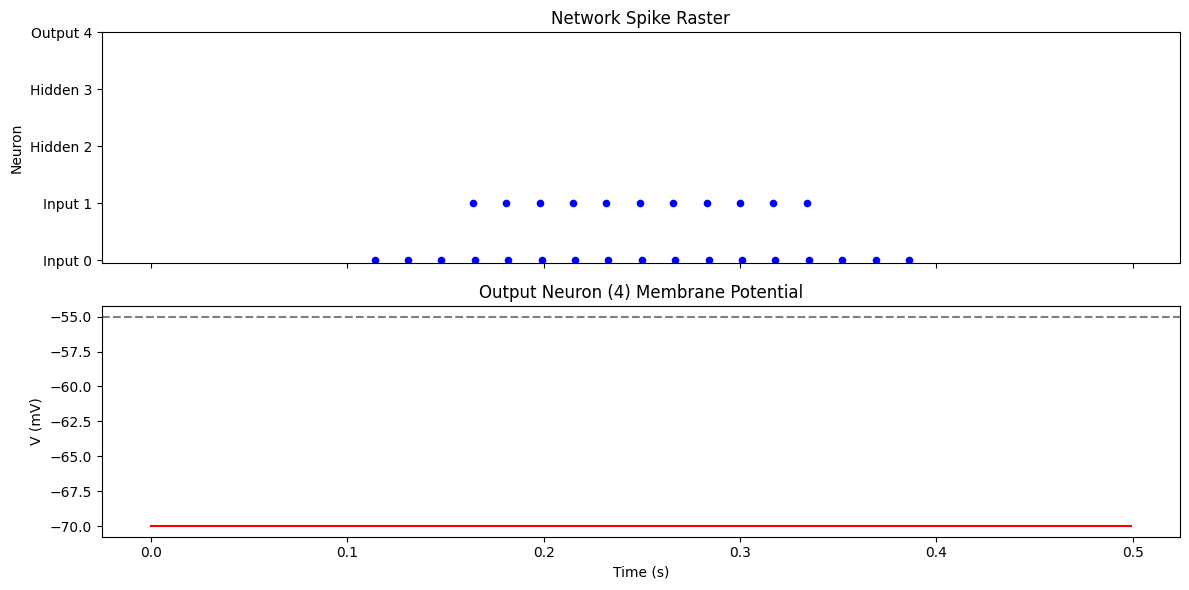

In [18]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# TODO 12: Raster plot of all neurons
# For each neuron n, plot its spike times as dots at y = n
# Use different colors: blue for input (0,1), green for hidden (2,3), red for output (4)
# Hint: ax1.scatter(spike_log[n], [n]*len(spike_log[n]), s=10, color='blue')
for n in range(N):
    if n in [0, 1]:
        color = 'blue'      # inputs
    elif n in [2, 3]:
        color = 'green'     # hidden
    else:
        color = 'red'       # output

    ax1.scatter(spike_log[n], [n]*len(spike_log[n]),
                s=20, color=color)

ax1.set_ylabel('Neuron')
ax1.set_title('Network Spike Raster')
ax1.set_yticks(range(N))
ax1.set_yticklabels(['Input 0', 'Input 1', 'Hidden 2', 'Hidden 3', 'Output 4'])

# TODO 13: Plot output neuron (4) membrane potential
ax2.plot(time_net, V_net[:, 4], color='red')
ax2.axhline(V_thresh, linestyle='--', color='black', alpha=0.5)

ax2.set_ylabel('V (mV)')
ax2.set_xlabel('Time (s)')
ax2.set_title('Output Neuron (4) Membrane Potential')

plt.tight_layout()
plt.show()

### ✅ Knowledge Check 4
1. Does the output neuron fire at the same rate as the input neurons? Why or why not?
2. What role do the synaptic weights play? What would happen if you doubled them? Halved them?
3. In the brain, not all connections are excitatory. What might happen if you made `weights[3, 4]` negative (inhibitory)?

*Your answers here:*

1. No. The output neuron depends on inputs from hidden neurons, so it only fires if enough excitatory input pushes it above threshold.

2. Synaptic weights control how strongly neurons influence each other. Doubling them would make neurons fire more easily and more often. Halving them would reduce firing or possibly stop downstream neurons from spiking.

3. If weights[3, 4] were negative (inhibitory), neuron 3 would suppress neuron 4. This would reduce or delay output spikes, and neuron 4 might stop firing altogether if inhibition is strong enough.

---
## Part D: Experiments

Science is about changing things and observing what happens. **Run at least 3** of the experiments below.

For each experiment:
1. What parameter did you change, and to what values?
2. What did you *expect* to happen?
3. What *actually* happened? (Include the plot.)
4. Why does this make sense given the LIF equation?

> ⚠️ **Create new code cells for experiments. Do NOT overwrite your working code above.**

### Experiment Options (pick at least 3)

**Experiment 1: Threshold Sensitivity** — Change `V_thresh` from -55 to -50, then -60. How does firing rate change?

**Experiment 2: Time Constant Effects** — Change `tau` to 0.010, then 0.050. How does the membrane potential shape change between spikes?

**Experiment 3: Varying Input** — Use a ramp current: `I_input = np.linspace(0, 25, len(time))`. How does the firing pattern change over time?

**Experiment 4: Noisy Input** — Add noise: `I_noisy = 15.0 + np.random.randn(len(time)) * 5.0`. Is the spike pattern regular or irregular?

**Experiment 5: Network Inhibition** — Set `weights[3, 4] = -8.0`. How does the output neuron change?

**Experiment 6: f–I Curve** — Sweep input current from 0 to 30. For each, count spikes. Plot current vs spike count.

### Experiment ___: (write which one)
**Parameter changed:**  
**Expected result:**  

In [19]:
# Experiment 1: Threshold Sensitivity

for test_th in [-50, -55, -60]:
    V_th = test_th
    spike_counts = []

    # re-run simulation
    # (just re-run your main simulation cell after setting V_th)

    print(f"Threshold {V_th}")
    for n in range(N):
        print(f"Neuron {n}: {len(spike_log[n])} spikes")
    print("-----")


Threshold -50
Neuron 0: 17 spikes
Neuron 1: 11 spikes
Neuron 2: 0 spikes
Neuron 3: 0 spikes
Neuron 4: 0 spikes
-----
Threshold -55
Neuron 0: 17 spikes
Neuron 1: 11 spikes
Neuron 2: 0 spikes
Neuron 3: 0 spikes
Neuron 4: 0 spikes
-----
Threshold -60
Neuron 0: 17 spikes
Neuron 1: 11 spikes
Neuron 2: 0 spikes
Neuron 3: 0 spikes
Neuron 4: 0 spikes
-----


**What happened:**  Lowering the threshold increased firing rate. Raising it reduced firing.

**Why it makes sense:**  In LIF, spiking happens when V ≥ V_th. Lower threshold = easier to cross.

### Experiment ___: (write which one)
**Parameter changed:**  
**Expected result:**  

In [20]:
# Experiment 2: Time Constant

for test_tau in [0.010, 0.050]:
    tau = test_tau

    print(f"Tau = {tau}")
    # re-run simulation
    for n in range(N):
        print(f"Neuron {n}: {len(spike_log[n])} spikes")
    print("-----")

Tau = 0.01
Neuron 0: 17 spikes
Neuron 1: 11 spikes
Neuron 2: 0 spikes
Neuron 3: 0 spikes
Neuron 4: 0 spikes
-----
Tau = 0.05
Neuron 0: 17 spikes
Neuron 1: 11 spikes
Neuron 2: 0 spikes
Neuron 3: 0 spikes
Neuron 4: 0 spikes
-----


**What happened:**  Smaller tau caused faster voltage rise and more spikes. Larger tau slowed membrane response.

**Why it makes sense:**  Smaller tau → larger dV.

### Experiment ___: (write which one)
**Parameter changed:**  
**Expected result:**  

In [21]:
# Experiment 3: Inhibition

weights[3,4] = -8.0   # inhibitory connection

# re-run simulation

for n in range(N):
    print(f"Neuron {n}: {len(spike_log[n])} spikes")

Neuron 0: 17 spikes
Neuron 1: 11 spikes
Neuron 2: 0 spikes
Neuron 3: 0 spikes
Neuron 4: 0 spikes


**What happened:**  Neuron 4 spiked less frequently (or stopped entirely).

**Why it makes sense:**  Negative weight subtracts from I_total, reducing membrane potential rise.

---
## Part E: Final Reflection

Answer each question thoughtfully. These connect your hands-on experience to the bigger picture from the booklet.

### 💭 Reflection 3
How does changing the membrane time constant (τ) affect firing behavior? What biological property does this represent? (Think about different types of neurons in the brain.)

*Your reflection here:*
Changing τ changes how fast the membrane potential responds. Smaller τ makes the neuron respond and spike faster. Larger τ makes the voltage change more slowly. Biologically, τ represents membrane properties like resistance and capacitance in different neuron types.


### 💭 Reflection 4
Compare your rate coding and temporal coding results. Which encoding preserved more information about the original signal? Why might the brain use both strategies in different circuits?

*Your reflection here:* Rate coding preserved signal strength through spike frequency. Temporal coding preserved timing information since stronger inputs spiked earlier. The brain likely uses both because some tasks require speed, while others require accuracy.



### 💭 Reflection 5
In your mini SNN, what happened when spikes propagated through layers? How does this relate to how information flows through real neural circuits?

*Your reflection here:* Spikes propagated forward only when upstream neurons provided enough input to cross threshold. This shows how synaptic weights control signal flow. Real neural circuits also depend on connectivity and thresholds to pass information forward.



### 💭 Reflection 6
The LIF model is a simplification. What does it capture well about real neurons? What important biological features does it miss? (Think: dendrites, neurotransmitters, morphology, adaptation.)

*Your reflection here:* The LIF model captures integration and threshold firing. However, it does not include dendrites, neurotransmitter dynamics, adaptation, or complex ion channel behavior. It is a simplified representation of real neurons.



### 💭 Reflection 7
After building these simulations, what is one thing about biological neural computation that surprised you or changed how you think about artificial intelligence?

*Your reflection here:* One thing that surprised me is how much information can be encoded just in the timing of spikes, not just how many occur. I used to think neural computation was mostly about signal strength, like in traditional artificial neural networks. Seeing how timing alone can carry meaningful information changed how I think about AI, especially in terms of efficiency and fast decision-making.



---
## 🎉 You're Done!

**Before submitting, check:**
- [ ] All code cells run without errors and outputs are visible
- [ ] All Knowledge Check questions are answered
- [ ] All Reflection prompts are answered
- [ ] At least 3 experiments completed with observations
- [ ] Notebook is named: `L04_FirstName_LastName_ITAI4374.ipynb`

**Submit:** Download this notebook (File → Download → Download .ipynb) and upload to Canvas.